# Customize Horn

Customize horn with inner outer diameters etc

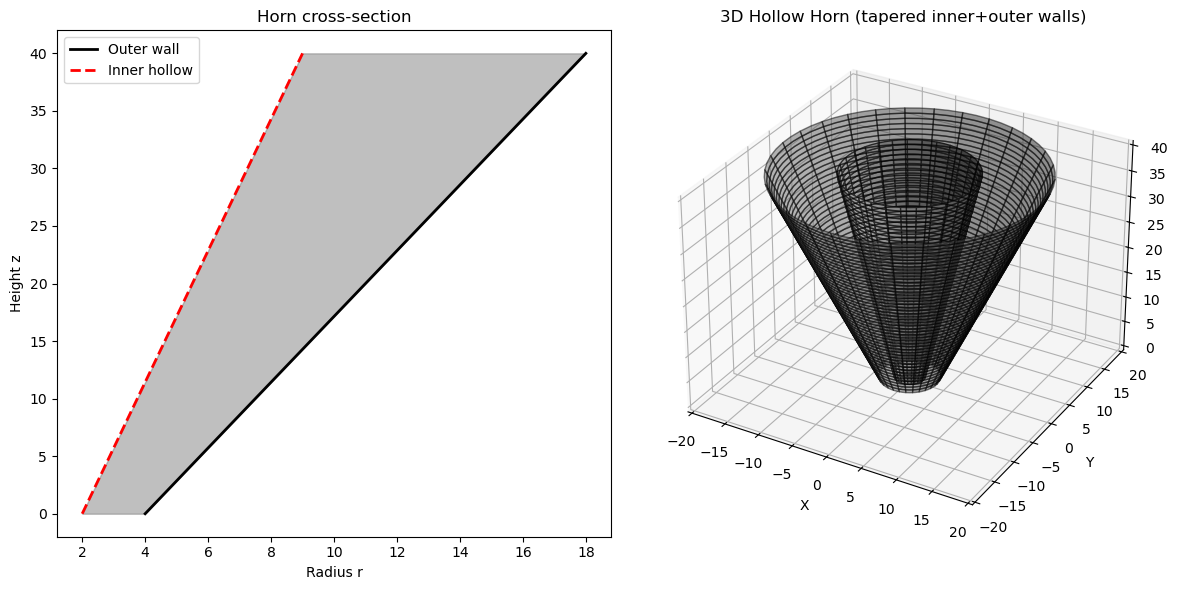

In [4]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pyvista as pv




def make_hollow_horn(r_in_start, r_in_end, r_out_start, r_out_end, h,
                     cthik=0.0, metal=True, n_cyl=2.0, n_slices=100):
    """
    Return geometry list for a hollow horn (flared cylinder) in cylindrical coordinates.

    r_in_start  : inner radius at the base
    r_in_end    : inner radius at the horn opening (top)
    r_out_start : outer radius at the base
    r_out_end   : outer radius at the horn opening (top)
    h           : height of the horn
    cthik       : offset multiplier in r-direction
    metal       : True for metal, False for dielectric
    n_cyl       : refractive index if dielectric
    n_slices    : number of slices to approximate the flare
    """
    if metal:
        material = mp.metal
    else:
        material = mp.Medium(index=n_cyl)

    geometry = []

    for i in range(n_slices):
        slice_height = h / n_slices
        z_mid = (i + 0.5) * slice_height

        # Linear taper for outer and inner radii
        slice_r_outer = r_out_start + (r_out_end - r_out_start) * (z_mid / h)
        slice_r_inner = r_in_start + (r_in_end - r_in_start) * (z_mid / h)

        # Outer wall (metal)
        geometry.append(
            mp.Block(
                material=material,
                center=mp.Vector3(cthik * slice_r_outer, 0, z_mid),
                size=mp.Vector3(slice_r_outer, 0, slice_height),
            )
        )

        # Hollow core (air)
        if slice_r_inner > 0:
            geometry.append(
                mp.Block(
                    material=mp.Medium(index=1.0),
                    center=mp.Vector3(cthik * slice_r_outer, 0, z_mid),
                    size=mp.Vector3(slice_r_inner, 0, slice_height),
                )
            )

    return geometry


def plot_hollow_horn_schematic(r_in_start, r_in_end,
                               r_out_start, r_out_end, h, n_slices=50):
    """
    Plot schematic (cross-section + 3D) of hollow horn geometry with tapered inner + outer walls.
    """
    fig = plt.figure(figsize=(12, 6))

    # --- 2D Cross-section (r vs z) ---
    ax1 = fig.add_subplot(121)
    z_vals = np.linspace(0, h, n_slices)
    r_outer_vals = np.linspace(r_out_start, r_out_end, n_slices)
    r_inner_vals = np.linspace(r_in_start, r_in_end, n_slices)

    ax1.plot(r_outer_vals, z_vals, "k-", lw=2, label="Outer wall")
    ax1.plot(r_inner_vals, z_vals, "r--", lw=2, label="Inner hollow")

    ax1.fill_betweenx(z_vals, r_inner_vals, r_outer_vals, color="grey", alpha=0.5)
    ax1.set_xlabel("Radius r")
    ax1.set_ylabel("Height z")
    ax1.set_title("Horn cross-section")
    ax1.legend()

    # --- 3D Visualization ---
    ax2 = fig.add_subplot(122, projection="3d")
    theta = np.linspace(0, 2*np.pi, 60)
    z_vals = np.linspace(0, h, n_slices)
    Theta, Z = np.meshgrid(theta, z_vals)

    # Outer surface
    R_outer_vals = np.linspace(r_out_start, r_out_end, n_slices)
    R_outer = np.tile(R_outer_vals[:, None], (1, len(theta)))
    X_outer = R_outer * np.cos(Theta)
    Y_outer = R_outer * np.sin(Theta)
    ax2.plot_surface(X_outer, Y_outer, Z, color="gray", alpha=0.5, edgecolor="k")

    # Inner hollow surface
    R_inner_vals = np.linspace(r_in_start, r_in_end, n_slices)
    R_inner = np.tile(R_inner_vals[:, None], (1, len(theta)))
    X_inner = R_inner * np.cos(Theta)
    Y_inner = R_inner * np.sin(Theta)
    ax2.plot_surface(X_inner, Y_inner, Z, color="white", alpha=1.0, edgecolor="k")

    ax2.set_title("3D Hollow Horn (tapered inner+outer walls)")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")

    plt.tight_layout()
    plt.show()


# --- Example usage ---
if __name__ == "__main__":
    r_in_start = 2     # inner radius at base
    r_in_end = 9       # inner radius at top
    r_out_start = 4    # outer radius at base
    r_out_end = 18     # outer radius at top
    h = 40             # height

    #geom = make_hollow_horn(r_in_start, r_in_end,
    #                        r_out_start, r_out_end, h, metal=True)

    plot_hollow_horn_schematic(r_in_start, r_in_end,
                               r_out_start, r_out_end, h)



## Meep cylindrical coord object

-----------
Initializing structure...
time for choose_chunkdivision = 5.00679e-06 s
Working in Cylindrical dimensions.
Computational cell is 0 x 0 x 52 with resolution 20
     cone, center = (0,0,0)
          radius 3, height 40, axis (0, 0, 1)
          radius2 18
          dielectric constant epsilon diagonal = (1e+20,1e+20,1e+20)
     cone, center = (0,0,0)
          radius 2, height 40, axis (0, 0, 1)
          radius2 9
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0 s
-----------
     cone, center = (0,0,0)
          radius 3, height 40, axis (0, 0, 1)
          radius2 18
          dielectric constant epsilon diagonal = (1e+20,1e+20,1e+20)
     cone, center = (0,0,0)
          radius 2, height 40, axis (0, 0, 1)
          radius2 9
          dielectric constant epsilon diagonal = (1,1,1)


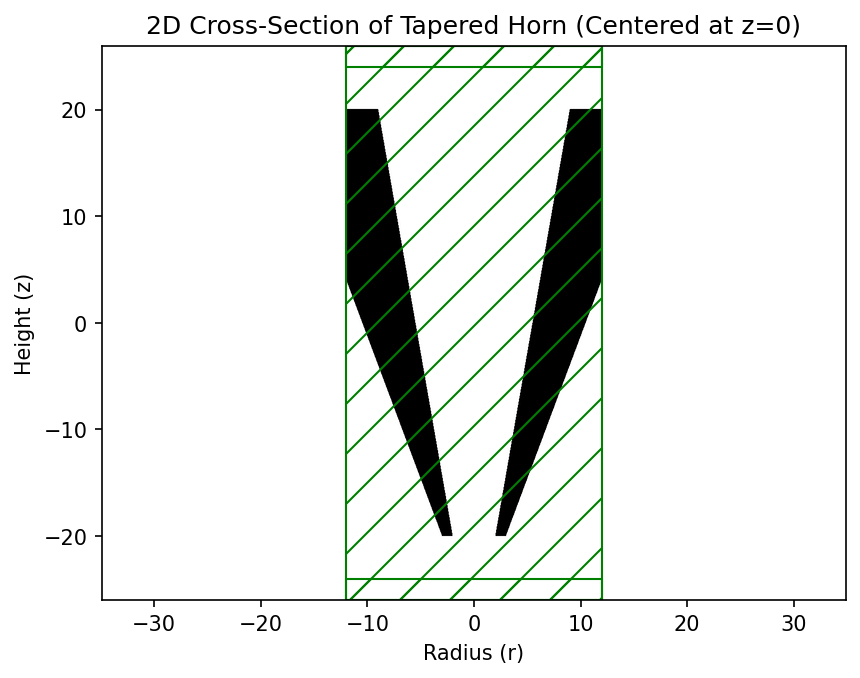

In [5]:
import meep as mp
import matplotlib.pyplot as plt
import numpy as np

# This script models the 2D cross-section of the tapered hollow horn antenna
# shown in the user-provided image. The simulation uses cylindrical coordinates.

# --- 1. Define Geometric Parameters from the Image ---

# The dimensions are estimated from the "Horn cross-section" plot.
horn_height = 40.0 # Height along the z-axis (from z=0 to z=40)

# Outer wall radii
r1_outer = 3.0  # Radius at the base (z=0)
r2_outer = 18.0 # Radius at the aperture (z=40)

# Inner hollow radii
r1_inner = 2.0  # Radius at the base (z=0)
r2_inner = 9.0  # Radius at the aperture (z=40)

# The center of the cone objects will be at half the height.
center_z = horn_height / 2

# --- 2. Set up Simulation Parameters ---

resolution = 20 # Pixels per distance unit

# Define padding and PML thickness for the computational cell
padding = 4.0
pml_thickness = 2.0

# Calculate cell dimensions to fit the geometry and PMLs
cell_r = r2_outer + padding + pml_thickness
cell_z = horn_height + 2 * padding + 2 * pml_thickness

# In Meep 2D cylindrical coordinates, the y-dimension represents the radial 'r'
# and the z-dimension represents the axial 'z'.
cell_size = mp.Vector3(y=cell_r, z=cell_z)

# Define the PML layers on all sides
pml_layers = [mp.PML(thickness=pml_thickness)]

# --- 3. Define Materials ---

# Define a Perfect Electric Conductor (PEC) for the metal horn walls
metal = mp.Medium(epsilon=mp.inf)
# Define air, which will be used to "carve out" the hollow part
air = mp.Medium(epsilon=1)

# --- 4. Create the Geometry ---

# The hollow cone is created by defining a large, solid metal cone and then
# placing a slightly smaller air cone inside it. In Meep's geometry list,
# the last object takes precedence in overlapping regions.
geometry = [
    # 1. Outer Cone (Solid Metal)
    mp.Cone(
        center=mp.Vector3(z=0), # Centered at z=0 for compatibility
        height=horn_height,
        radius=r1_outer,
        radius2=r2_outer,
        axis=mp.Vector3(z=1),
        material=metal,
    ),
    # 2. Inner Cone (Solid Air to create the hollow part)
    mp.Cone(
        center=mp.Vector3(z=0), # Centered at z=0 for compatibility
        height=horn_height,
        radius=r1_inner,
        radius2=r2_inner,
        axis=mp.Vector3(z=1),
        material=air,
    ),
]

# --- 5. Set up Simulation and Visualize ---

sim = mp.Simulation(
    cell_size=cell_size,
    geometry=geometry,
    boundary_layers=pml_layers,
    resolution=resolution,
    # This is the key setting to enable cylindrical coordinates
    dimensions=mp.CYLINDRICAL
    # The 'cell_center' argument is removed for compatibility with older
    # Meep versions. The geometry is now manually centered at z=0.
)

# Initialize the simulation to set up the grid with our geometry
sim.init_sim()

# --- 6. Plot the Geometry ---

# Use Meep's built-in plot2D function for robust visualization.
# This will show the epsilon distribution in the r-z plane.
plt.figure(dpi=150)
sim.plot2D()
plt.title("2D Cross-Section of Tapered Horn (Centered at z=0)")
plt.xlabel("Radius (r)")
plt.ylabel("Height (z)")
plt.axis('equal') # Ensure the aspect ratio is correct
plt.show()



## show 3d

In [6]:
def visualize_meep_geometry(geometry, show_material=True):
    """
    Visualize a Meep geometry list with PyVista.

    Supports: mp.Block, mp.Cylinder, mp.Sphere, mp.Cone
    """
    plotter = pv.Plotter()

    for i, obj in enumerate(geometry):
        # --- choose color ---
        if not show_material:
            color = "gray"
        else:
            if obj.material == mp.metal:
                color = "silver"
            elif isinstance(obj.material, mp.Medium) and getattr(obj.material, "epsilon_diag", None):
                color = "green"   # dielectric
            else:
                color = "lightblue"  # air or generic

        # --- Block ---
        if isinstance(obj, mp.Block):
            sx, sy, sz = obj.size.x, obj.size.y, obj.size.z
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            sy = sy if sy > 0 else 0.01  # avoid degenerate case
            block = pv.Cube(center=(cx, cy, cz), x_length=sx, y_length=sy, z_length=sz)
            plotter.add_mesh(block, opacity=0.6, color=color, show_edges=True)

        # --- Cylinder ---
        elif isinstance(obj, mp.Cylinder):
            r = obj.radius
            h = obj.height
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            cyl = pv.Cylinder(center=(cx, cy, cz), radius=r, height=h, direction=(0,0,1))
            plotter.add_mesh(cyl, opacity=0.6, color=color, show_edges=True)

        # --- Sphere ---
        elif isinstance(obj, mp.Sphere):
            r = obj.radius
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            sph = pv.Sphere(radius=r, center=(cx, cy, cz))
            plotter.add_mesh(sph, opacity=0.6, color=color, show_edges=True)

        # --- Cone ---
        elif isinstance(obj, mp.Cone):
            r1 = obj.radius  # base radius
            r2 = obj.radius2 # top radius
            h  = obj.height
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z

            cone = pv.Cone(center=(cx, cy, cz - h/2), 
                           direction=(0,0,1), 
                           height=h, 
                           radius=r1, 
                           capping=True)

            if r2 > 0:
                # Truncated cone (frustum)
                cone = pv.Cone(center=(cx, cy, cz - h/2), 
                               direction=(0,0,1), 
                               height=h, 
                               radius=r1, 
                               capping=True).boolean_cut(
                           pv.Cone(center=(cx, cy, cz - h/2), 
                                   direction=(0,0,1), 
                                   height=h, 
                                   radius=r2, 
                                   capping=True))

            plotter.add_mesh(cone, opacity=0.6, color=color, show_edges=True)

        else:
            print(f"⚠️ Unsupported geometry type: {type(obj)}")

    plotter.show_grid()
    plotter.show()

/opt/anaconda3/envs/meep/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


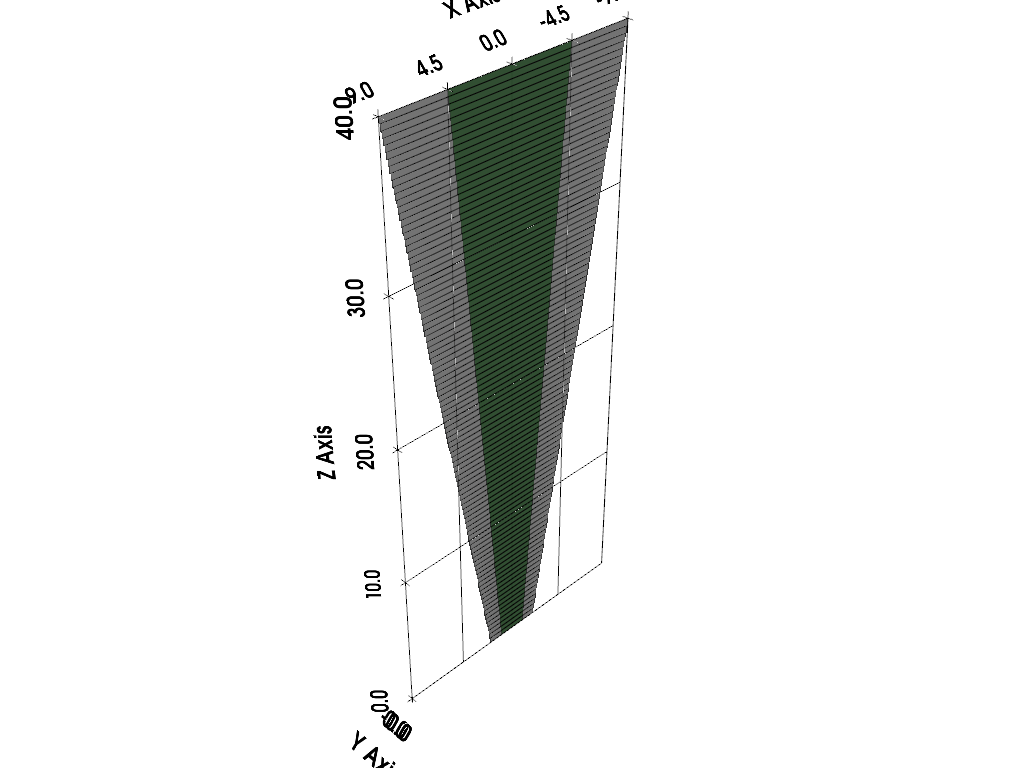

: 

In [7]:
visualize_meep_geometry(geom)